# La Liga Market Value Analysis — Data Cleaning (Sections 1–4)
**Notebook:** `01_data_cleaning.ipynb`

This notebook loads and cleans the two data sources I used for the La Liga market value analysis.

| # | Section | Output |
|---|---------|--------|
| 1 | Data Loading | Raw DataFrames inspected |
| 2 | Filter Transfermarkt for La Liga | ES1-only subsets, season labels |
| 3 | Data Quality Audit | Null/duplicate reports, distributions |
| 4 | Merge | `laliga_merged.csv` |


---
## 1. Data Loading

This project uses two data sources:

**Understat** (`understat_laliga_2014_2024.csv`) — scraped from understat.com using the site's internal API. Each row is one player's stats for one La Liga season, with metrics like xG, xA, goals, assists, and minutes played.

**Transfermarkt** (files in `transfermarkt_data/`) — downloaded from Kaggle (`davidcariboo/player-scores`, CC0 licence). The three files used here are:
- `players.csv` — basic player info (position, nationality, date of birth, market value)
- `player_valuations.csv` — a history of market value snapshots per player and date
- `competitions.csv` — used to find the La Liga competition code (`ES1`)


In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import unicodedata
import re
import warnings
warnings.filterwarnings('ignore')

# Ruta de los archivos de Transfermarkt
ruta_tm = "transfermarkt_data/"

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


### 1.1 Understat — player statistics


In [2]:
# Cargar el dataset de estadísticas de Understat
understat = pd.read_csv("understat_laliga_2014_2024.csv")

print(f"Shape: {understat.shape}")
print(f"\nColumnas ({len(understat.columns)}):")
print(list(understat.columns))


Shape: (6192, 15)

Columnas (15):
['player_id', 'player_name', 'games', 'time', 'goals', 'xG', 'assists', 'xA', 'shots', 'key_passes', 'position', 'team_title', 'npg', 'npxG', 'season']


In [3]:
understat.head()


,player_id,player_name,games,time,goals,xG,assists,xA,shots,key_passes,position,team_title,npg,npxG,season
0,2371,Cristiano Ronaldo,35,3103,48,39.308746,16,13.600629,225,76,F M,Real Madrid,38,30.389681,2014/15
1,2097,Lionel Messi,38,3374,43,35.891770,18,17.611949,187,95,F S,Barcelona,38,31.432102,2014/15
2,2099,Neymar,33,2573,22,22.721615,7,8.261539,95,52,F S,Barcelona,21,21.978335,2014/15
3,2270,Antoine Griezmann,37,2490,22,14.709659,1,2.607721,78,23,F M S,Atletico Madrid,22,14.709659,2014/15
4,1125,Carlos Bacca,37,2581,20,19.279248,6,4.728216,69,31,F S,Sevilla,14,13.333664,2014/15


### 1.2 Transfermarkt — `players.csv`


In [4]:
# Cargar metadatos estáticos de jugadores
tm_players = pd.read_csv(ruta_tm + "players.csv")

print(f"Shape: {tm_players.shape}")
print(f"\nColumnas ({len(tm_players.columns)}):")
print(list(tm_players.columns))


Shape: (34320, 23)

Columnas (23):
['player_id', 'first_name', 'last_name', 'name', 'last_season', 'current_club_id', 'player_code', 'country_of_birth', 'city_of_birth', 'country_of_citizenship', 'date_of_birth', 'sub_position', 'position', 'foot', 'height_in_cm', 'contract_expiration_date', 'agent_name', 'image_url', 'url', 'current_club_domestic_competition_id', 'current_club_name', 'market_value_in_eur', 'highest_market_value_in_eur']


In [5]:
tm_players.head()


,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,foot,height_in_cm,contract_expiration_date,agent_name,image_url,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
0,10,Miroslav,Klose,Miroslav Klose,2015,398,miroslav-klose,Poland,Opole,Germany,...,right,184.0,NaN,ASBW Sport Marketing,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/miroslav-klose...,IT1,Società Sportiva Lazio S.p.A.,1000000.0,30000000.0
1,26,Roman,Weidenfeller,Roman Weidenfeller,2017,16,roman-weidenfeller,Germany,Diez,Germany,...,left,190.0,NaN,Neubauer 13 GmbH,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/roman-weidenfe...,L1,Borussia Dortmund,750000.0,8000000.0
2,65,Dimitar,Berbatov,Dimitar Berbatov,2015,1091,dimitar-berbatov,Bulgaria,Blagoevgrad,Bulgaria,...,NaN,NaN,NaN,CSKA-AS-23 Ltd.,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/dimitar-berbat...,GR1,Panthessalonikios Athlitikos Omilos Konstantin...,1000000.0,34500000.0
3,77,NaN,Lúcio,Lúcio,2012,506,lucio,Brazil,Brasília,Brazil,...,NaN,NaN,NaN,NaN,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/lucio/profil/s...,IT1,Juventus Football Club,200000.0,24500000.0
4,80,Tom,Starke,Tom Starke,2017,27,tom-starke,East Germany (GDR),Freital,Germany,...,right,194.0,NaN,IFM,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/tom-starke/pro...,L1,FC Bayern München,100000.0,3000000.0


### 1.3 Transfermarkt — `player_valuations.csv`


In [6]:
# Cargar historial de valoraciones de mercado
tm_val = pd.read_csv(ruta_tm + "player_valuations.csv")

print(f"Shape: {tm_val.shape}")
print(f"\nColumnas ({len(tm_val.columns)}):")
print(list(tm_val.columns))


Shape: (435443, 6)

Columnas (6):
['player_id', 'date', 'market_value_in_eur', 'current_club_name', 'current_club_id', 'player_club_domestic_competition_id']


In [7]:
tm_val.head()


,player_id,date,market_value_in_eur,current_club_name,current_club_id,player_club_domestic_competition_id
0,405973,2000-01-20,150000,Unknown,3057.0,BE1
1,342216,2001-07-20,100000,Unknown,1241.0,SC1
2,3132,2003-12-09,400000,Dynamo Kyiv,126.0,TR1
3,6893,2003-12-15,900000,Galatasaray,984.0,GB1
4,12359,2004-03-11,250000,RC Lens B,8152.0,NaN


### 1.4 Transfermarkt — `competitions.csv`


In [8]:
# Cargar catálogo de competiciones y mostrar la fila de La Liga
tm_comp = pd.read_csv(ruta_tm + "competitions.csv")

print(f"Shape: {tm_comp.shape}")
print(f"\nFila ES1 (La Liga):")
print(tm_comp[tm_comp['competition_id'] == 'ES1'].to_string())


Shape: (44, 11)

Fila ES1 (La Liga):
   competition_id competition_code    name    sub_type             type  country_id country_name domestic_league_code confederation                                                               url  is_major_national_league
14            ES1           laliga  laliga  first_tier  domestic_league         157        Spain                  ES1        europa  https://www.transfermarkt.co.uk/laliga/startseite/wettbewerb/ES1                      True


---
## 2. Filter Transfermarkt for La Liga

The Transfermarkt files cover many different leagues. Here we keep only La Liga (`ES1`) entries and limit the years to 2014–2024 to match the Understat data.

### Season convention
A football season spans two calendar years (e.g. 2014/15 runs from August 2014 to May 2015).
We assign each valuation date to a season using the rule:

| Month of valuation date | Season start year |
|-------------------------|-------------------|
| August – December | Same year |
| January – July | Year before |

For example, a valuation from March 2015 belongs to season **2014/15**, while one from September 2015 belongs to **2015/16**.


In [9]:
# jugadores con club actual en la liga
tm_players_es1 = tm_players[
    tm_players['current_club_domestic_competition_id'] == 'ES1'
].copy()

print(f"players.csv — total:          {len(tm_players):>7,}")
print(f"players.csv — ES1 only:       {len(tm_players_es1):>7,}")

print(f"jugadores en La Liga: {len(tm_players_es1)}")

players.csv — total:           34,320
players.csv — ES1 only:         2,331
jugadores en La Liga: 2331


In [10]:
# valoraciones correspondientes a la liga
tm_val_es1 = tm_val[
    tm_val['player_club_domestic_competition_id'] == 'ES1'
].copy()

print(f"player_valuations.csv — total:     {len(tm_val):>8,}")
print(f"player_valuations.csv — ES1 only:  {len(tm_val_es1):>8,}")


player_valuations.csv — total:      435,443
player_valuations.csv — ES1 only:    33,284


In [11]:
# filtrar 2014–2024 y asignar etiqueta de temporada

# Convertir columna de fecha a datetime
tm_val_es1['date'] = pd.to_datetime(tm_val_es1['date'])

# Extraer año y filtrar rango
tm_val_es1['year'] = tm_val_es1['date'].dt.year
mask_years = tm_val_es1['year'].between(2014, 2024)
tm_val_es1 = tm_val_es1[mask_years].copy()

print(f"player_valuations.csv — ES1, 2014-2024: {len(tm_val_es1):>7,}")
print(f"Rango de fechas: {tm_val_es1['date'].min().date()}  →  {tm_val_es1['date'].max().date()}")

print(f"valoraciones en rango 2014-2024: {len(tm_val_es1)}")

player_valuations.csv — ES1, 2014-2024:  24,426


Rango de fechas: 2014-01-02  →  2024-12-03
valoraciones en rango 2014-2024: 24426


In [12]:
# calcular el año de inicio de temporada según el mes de la valoración
def asignar_temporada(fila):
    anio = fila['year']
    mes = fila['date'].month
    if mes >= 8:
        return anio
    else:
        return anio - 1

tm_val_es1['season_start'] = tm_val_es1.apply(asignar_temporada, axis=1)

# crear etiqueta de temporada en formato "YYYY/YY"
def formato_temporada(y):
    fin = str(y + 1)[-2:]
    return f"{y}/{fin}"

tm_val_es1['season'] = tm_val_es1['season_start'].apply(formato_temporada)

# excluir valoraciones de 2013/14 que aparecen por fechas de enero-julio 2014
tm_val_es1 = tm_val_es1[tm_val_es1['season_start'] >= 2014].copy()

print(f"Filas tras excluir temporada 2013/14: {len(tm_val_es1):>7,}")
print(f"Temporadas únicas: {sorted(tm_val_es1['season'].unique())}")


Filas tras excluir temporada 2013/14:  23,382
Temporadas únicas: ['2014/15', '2015/16', '2016/17', '2017/18', '2018/19', '2019/20', '2020/21', '2021/22', '2022/23', '2023/24', '2024/25']


In [13]:
# quedarse con la última valoración por jugador y temporada
tm_val_ordenado = tm_val_es1.sort_values('date')
tm_val_season = tm_val_ordenado.groupby(['player_id', 'season'], as_index=False).last()

print(f"Snapshots únicos (player_id × season): {len(tm_val_season):>6,}")
print(f"Jugadores distintos con al menos una valoración: {tm_val_season['player_id'].nunique():>6,}")
tm_val_season[['player_id', 'season', 'date', 'market_value_in_eur', 'current_club_name']].head(8)


Snapshots únicos (player_id × season): 10,995
Jugadores distintos con al menos una valoración:  2,230


,player_id,season,date,market_value_in_eur,current_club_name
0,215,2015/16,2016-02-22,1000000,Málaga CF
1,215,2016/17,2016-08-15,500000,Olimpia Asunción
2,215,2017/18,2017-11-30,250000,Olimpia Asunción
3,215,2019/20,2020-03-02,250000,Olimpia Asunción
4,215,2020/21,2021-06-28,250000,Olimpia Asunción
5,215,2021/22,2022-06-14,250000,Club Libertad Asunción
6,215,2022/23,2023-06-30,250000,Club Libertad Asunción
7,277,2014/15,2015-07-01,350000,Fortuna Düsseldorf


---
## 3. Data Quality Audit

I check missing values, duplicate keys, and the distributions of the main variables before merging: **player position** (Understat) and **market value** (Transfermarkt).


### 3.1 Missing values


In [14]:
# nulos en understat
print("=== UNDERSTAT — Missing values ===")
null_us = understat.isnull().sum()
if null_us.sum() == 0:
    print("No missing values found.")
else:
    print(null_us[null_us > 0].to_string())
    print(f"  Total cells missing: {null_us.sum()}")


=== UNDERSTAT — Missing values ===
No missing values found.


In [15]:
# nulos en valoraciones transfermarkt (es1, 2014-2024)
print("=== TRANSFERMARKT VALUATIONS (ES1, 2014-2024) — Missing values ===")
null_tm = tm_val_season.isnull().sum()
null_tm_nonzero = null_tm[null_tm > 0]
if len(null_tm_nonzero) == 0:
    print("No missing values found.")
else:
    pct = (null_tm_nonzero / len(tm_val_season) * 100).round(1)
    summary = pd.DataFrame({'missing': null_tm_nonzero, 'pct (%)': pct})
    print(summary.to_string())


=== TRANSFERMARKT VALUATIONS (ES1, 2014-2024) — Missing values ===
No missing values found.


### 3.2 Duplicate keys


In [16]:
# duplicados en understat: clave (player_id, season)
dup_us = understat.duplicated(subset=['player_id', 'season']).sum()

# duplicados en transfermarkt: clave (player_id, season)
dup_tm = tm_val_season.duplicated(subset=['player_id', 'season']).sum()

print(f"Understat — duplicate (player_id, season) rows:          {dup_us}")
print(f"Transfermarkt — duplicate (player_id, season) rows:      {dup_tm}")
print()
if dup_us == 0 and dup_tm == 0:
    print("Both datasets have unique keys → safe to merge 1-to-1 per (player, season).")


Understat — duplicate (player_id, season) rows:          0
Transfermarkt — duplicate (player_id, season) rows:      0

Both datasets have unique keys → safe to merge 1-to-1 per (player, season).


### 3.3 Position distribution (Understat)


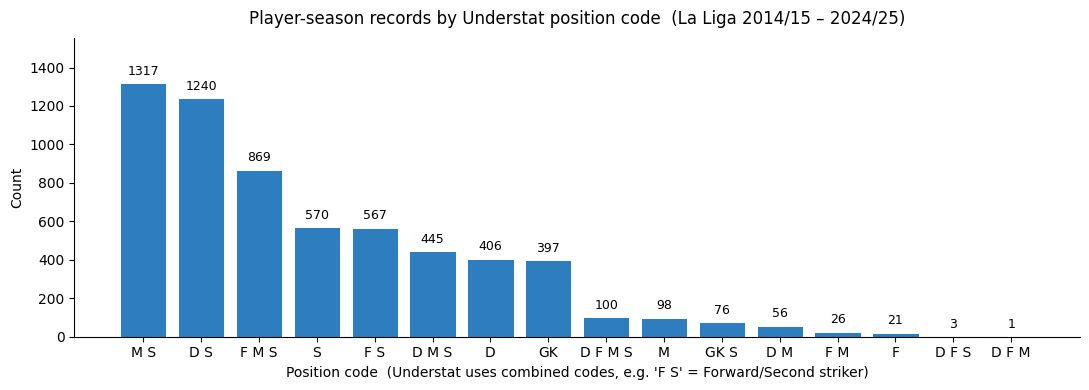


Frequency table:
position
M S        1317
D S        1240
F M S       869
S           570
F S         567
D M S       445
D           406
GK          397
D F M S     100
M            98
GK S         76
D M          56
F M          26
F            21
D F S         3
D F M         1


In [17]:
# distribución de posiciones
pos_counts = understat['position'].value_counts()

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(pos_counts.index, pos_counts.values, color='#2E7EBF', edgecolor='white', linewidth=0.7)
ax.bar_label(bars, padding=4, fontsize=9, fmt='%d')
ax.set_title("Player-season records by Understat position code  (La Liga 2014/15 – 2024/25)",
             fontsize=12, pad=10)
ax.set_xlabel("Position code  (Understat uses combined codes, e.g. 'F S' = Forward/Second striker)")
ax.set_ylabel("Count")
ax.set_ylim(0, pos_counts.max() * 1.18)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig("figures/fig_01_position_distribution.png", dpi=130, bbox_inches='tight')
plt.show()

print("\nFrequency table:")
print(pos_counts.to_string())


### 3.4 Market value distribution (Transfermarkt, La Liga ES1)


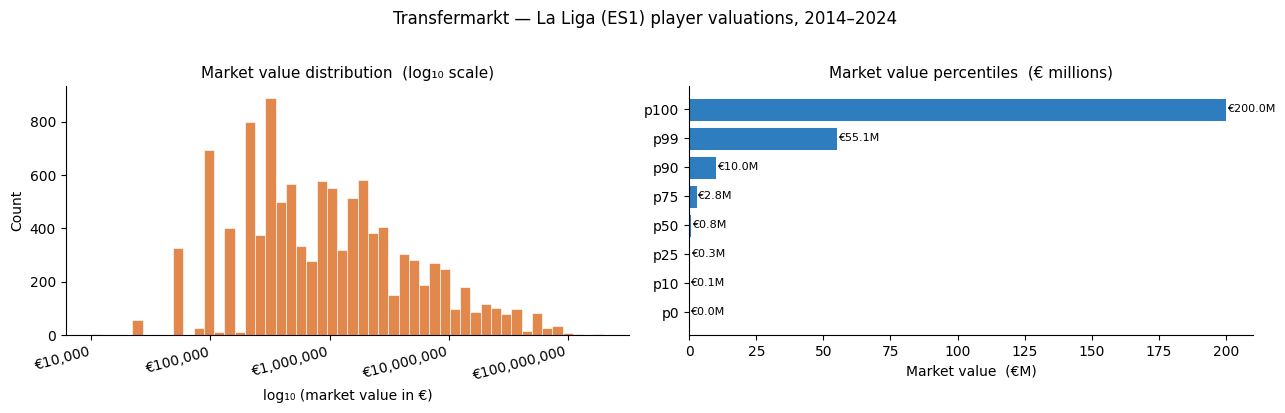

Market value descriptive statistics:
count    €        10,995
mean     €     4,045,765
std      €    10,690,996
min      €        10,000
25%      €       300,000
50%      €       800,000
75%      €     2,800,000
max      €   200,000,000
Name: market_value_in_eur, dtype: str


In [18]:
# distribución del valor de mercado (escala logarítmica)
mv = tm_val_season['market_value_in_eur'].dropna()
mv_pos = mv[mv > 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Panel izquierdo: histograma en escala log₁₀
log_mv = np.log10(mv_pos)
axes[0].hist(log_mv, bins=50, color='#E07B39', edgecolor='white', linewidth=0.5, alpha=0.9)
axes[0].set_title("Market value distribution  (log₁₀ scale)", fontsize=11)
axes[0].set_xlabel("log₁₀ (market value in €)")
axes[0].set_ylabel("Count")
ticks = [4, 5, 6, 7, 8]
axes[0].set_xticks(ticks)
axes[0].set_xticklabels([f"€{10**t:,.0f}" for t in ticks], rotation=15, ha='right')
axes[0].spines[['top','right']].set_visible(False)

# Panel derecho: percentiles del valor de mercado
percentiles = [0, 10, 25, 50, 75, 90, 99, 100]
pct_vals = np.percentile(mv_pos, percentiles)
axes[1].barh([f"p{p}" for p in percentiles], pct_vals / 1e6,
             color='#2E7EBF', edgecolor='white', linewidth=0.7)
axes[1].set_title("Market value percentiles  (€ millions)", fontsize=11)
axes[1].set_xlabel("Market value  (€M)")
axes[1].spines[['top','right']].set_visible(False)
for i, (p, v) in enumerate(zip(percentiles, pct_vals)):
    axes[1].text(v / 1e6 + 0.3, i, f"€{v/1e6:.1f}M", va='center', fontsize=8)

plt.suptitle("Transfermarkt — La Liga (ES1) player valuations, 2014–2024",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("figures/fig_02_market_value_distribution.png", dpi=130, bbox_inches='tight')
plt.show()

print("Market value descriptive statistics:")
print(mv_pos.describe().apply(lambda x: f"€{x:>14,.0f}"))


---
## 4. Merge — Understat × Transfermarkt

Player names are stored differently across the two sources (accents, abbreviations, word order).
I used two passes to match as many players as possible without too many false matches:

| Pass | Method | Threshold |
|------|--------|-----------|
| 1 | Exact match on cleaned name + season | — |
| 2 | Fuzzy match (rapidfuzz score) on leftovers | ≥ 85 |

**Name cleaning** removes accents, converts to lowercase, and strips punctuation so that names like *"Vinícius Júnior"* and *"Vinicius Junior"* are treated as identical.

`token_sort_ratio` sorts the words in a name alphabetically before comparing, so "da Silva Marco" and "Marco da Silva" end up as the same string. This handles reversed name formats between the two datasets.


In [19]:
# añadir nombre del jugador a la tabla de valoraciones
# player_valuations sólo tiene player_id; el nombre viene de players.csv
tm_names = tm_players[['player_id', 'name']].rename(columns={'name': 'tm_name'})

tm_val_named = tm_val_season.merge(tm_names, on='player_id', how='left')

n_without_name = tm_val_named['tm_name'].isna().sum()
print(f"Valoraciones ES1 con nombre del jugador: {len(tm_val_named):>6,}")
print(f"  → player_id sin match en players.csv:  {n_without_name:>6,}")


Valoraciones ES1 con nombre del jugador: 10,995
  → player_id sin match en players.csv:       1


In [20]:
# normaliza el nombre: sin acentos, minúsculas, sin puntuación
def normalize_name(name):
    if pd.isna(name) or str(name).strip() == '':
        return ''
    # Descomponer caracteres Unicode (ó → o + combining accent)
    nfkd = unicodedata.normalize('NFKD', str(name))
    # Conservar sólo caracteres ASCII
    ascii_str = nfkd.encode('ascii', 'ignore').decode('ascii')
    # Minúsculas, sólo letras y espacios
    return re.sub(r'[^a-z ]', '', ascii_str.lower()).strip()

# Aplicar normalización en ambos datasets
understat['name_norm']    = understat['player_name'].apply(normalize_name)
tm_val_named['name_norm'] = tm_val_named['tm_name'].apply(normalize_name)

# Verificar con ejemplos
sample = (understat[['player_name', 'name_norm']]
          .drop_duplicates()
          .sample(10, random_state=42))
print("Ejemplos de normalización:")
print(sample.to_string(index=False))


Ejemplos de normalización:
      player_name         name_norm
     Rubén Duarte      ruben duarte
     Luis Martins      luis martins
   Yannis Salibur    yannis salibur
   Dani Rodríguez    dani rodriguez
    Jaime Gavilán     jaime gavilan
            Luque             luque
Eduard Campabadal eduard campabadal
   Julián Álvarez    julian alvarez
  Matija Nastasic   matija nastasic
  Largie Ramazani   largie ramazani


In [21]:
# paso 1: join exacto por (name_norm, season)

# Columnas de Transfermarkt que queremos incorporar
cols_tm = ['name_norm', 'season', 'player_id', 'tm_name',
           'market_value_in_eur', 'date', 'current_club_name']

exact_merged = understat.merge(
    tm_val_named[cols_tm].rename(columns={
        'player_id':    'tm_player_id',
        'date':         'valuation_date',
        'current_club_name': 'tm_club',
    }),
    on=['name_norm', 'season'],
    how='inner'
)

# Filas de Understat sin match exacto — irán a fuzzy
matched_keys = set(zip(exact_merged['name_norm'], exact_merged['season']))
unmatched_us = understat[
    ~understat.apply(lambda r: (r['name_norm'], r['season']) in matched_keys, axis=1)
].copy()

print(f"Understat total rows:                     {len(understat):>6,}")
print(f"  Matched (exact join):                   {len(exact_merged):>6,}")
print(f"  Unmatched → going to fuzzy:             {len(unmatched_us):>6,}")


Understat total rows:                      6,192
  Matched (exact join):                    3,600
  Unmatched → going to fuzzy:              2,643


In [22]:
# paso 2: fuzzy matching sobre los no-matcheados
from rapidfuzz import fuzz, process

# Umbral de 85 sobre 100 — elegido después de probar valores entre
# 70 y 90 y revisar manualmente los resultados
THRESHOLD = 85   # similitud mínima token_sort_ratio para aceptar un match

# Construir lookup por temporada: {season → {name_norm → {...tm data...}}}
def build_lookup(df: pd.DataFrame) -> dict:
    lookup = {}
    for _, row in df.dropna(subset=['name_norm']).iterrows():
        s = row['season']
        if s not in lookup:
            lookup[s] = {}
        lookup[s][row['name_norm']] = {
            'tm_player_id':      row['player_id'],
            'tm_name':           row['tm_name'],
            'market_value_in_eur': row['market_value_in_eur'],
            'valuation_date':    row['date'],
            'tm_club':           row['current_club_name'],
        }
    return lookup

season_lookup = build_lookup(tm_val_named)

fuzzy_rows = []

for _, row in unmatched_us.iterrows():
    season = row['season']
    q      = row['name_norm']

    if season not in season_lookup or not q:
        fuzzy_rows.append({**row.to_dict(), 'match_type': 'no_match', 'fuzzy_score': np.nan,
                           'tm_player_id': np.nan, 'tm_name': np.nan,
                           'market_value_in_eur': np.nan, 'valuation_date': pd.NaT, 'tm_club': np.nan})
        continue

    candidates = list(season_lookup[season].keys())
    result = process.extractOne(q, candidates, scorer=fuzz.token_sort_ratio)

    if result is None:
        score, best = 0, None
    else:
        best, score, _ = result

    if score >= THRESHOLD:
        tm_info = season_lookup[season][best]
        fuzzy_rows.append({**row.to_dict(), 'match_type': 'fuzzy', 'fuzzy_score': score, **tm_info})
    else:
        fuzzy_rows.append({**row.to_dict(), 'match_type': 'no_match',
                           'fuzzy_score': score if result else np.nan,
                           'tm_player_id': np.nan, 'tm_name': np.nan,
                           'market_value_in_eur': np.nan, 'valuation_date': pd.NaT, 'tm_club': np.nan})

fuzzy_df = pd.DataFrame(fuzzy_rows)

n_fuzzy_ok  = (fuzzy_df['match_type'] == 'fuzzy').sum()
n_no_match  = (fuzzy_df['match_type'] == 'no_match').sum()

print(f"Fuzzy pass — candidates processed:        {len(fuzzy_df):>6,}")
print(f"  Matched (score ≥ {THRESHOLD}):              {n_fuzzy_ok:>6,}")
print(f"  Unmatched (below threshold):            {n_no_match:>6,}")


Fuzzy pass — candidates processed:         2,643
  Matched (score ≥ 85):                 159
  Unmatched (below threshold):             2,484


In [23]:
# combinar exact + fuzzy y calcular resumen del merge

# Añadir metadatos de merge al join exacto
exact_merged['match_type']  = 'exact'
exact_merged['fuzzy_score'] = 100.0

# Sólo los fuzzy que tuvieron match válido
fuzzy_ok = fuzzy_df[fuzzy_df['match_type'] == 'fuzzy'].copy()

# Columnas comunes a ambos DataFrames
shared_cols = [c for c in exact_merged.columns if c in fuzzy_ok.columns]
merged = pd.concat([exact_merged[shared_cols], fuzzy_ok[shared_cols]], ignore_index=True)

print("=" * 55)
print("MERGE SUMMARY")
print("=" * 55)
print(f"  Understat rows (input):            {len(understat):>6,}")
print(f"  Exact matches:                     {len(exact_merged):>6,}")
print(f"  Fuzzy matches (score ≥ {THRESHOLD}):      {len(fuzzy_ok):>6,}")
print(f"  Total matched:                     {len(merged):>6,}  "
      f"({len(merged)/len(understat)*100:.1f}% of Understat)")
print(f"  Unmatched (excluded):              {n_no_match:>6,}  "
      f"({n_no_match/len(understat)*100:.1f}% of Understat)")
print("=" * 55)
print(f"\nMerged dataset shape: {merged.shape}")


MERGE SUMMARY
  Understat rows (input):             6,192
  Exact matches:                      3,600
  Fuzzy matches (score ≥ 85):         159
  Total matched:                      3,759  (60.7% of Understat)
  Unmatched (excluded):               2,484  (40.1% of Understat)

Merged dataset shape: (3759, 23)


### 4.6 Match quality inspection


In [24]:
# 4.6a  ejemplos de matches fuzzy exitosos (score más bajo primero)
print("=== FUZZY MATCHES — lowest scores first (borderline cases) ===")
fuzzy_ok_view = (fuzzy_ok[['player_name', 'tm_name', 'fuzzy_score', 'season']]
                 .sort_values('fuzzy_score')
                 .drop_duplicates(subset=['player_name', 'tm_name'])
                 .head(20))
print(fuzzy_ok_view.to_string(index=False))


=== FUZZY MATCHES — lowest scores first (borderline cases) ===
         player_name          tm_name  fuzzy_score  season
           De Marcos     Marcos André    85.714286 2024/25
      Iván Rodríguez   Juan Rodríguez    85.714286 2017/18
      Antonio Sivera   Antonio Valera    85.714286 2018/19
      Cristian Ganea   Cristian Galas    85.714286 2018/19
       Sergio Cubero  Sergio Escudero    85.714286 2020/21
Stephane Paul Keller  Stephane Keller    85.714286 2020/21
         David López       Javi López    85.714286 2018/19
             Rodrigo          Rodrygo    85.714286 2016/17
      Javi Hernández   Juan Hernández    85.714286 2022/23
       Ferrán Torres  Fernando Torres    85.714286 2018/19
      Dani Rodríguez   Javi Rodríguez    85.714286 2024/25
     Marcos de Sousa  Óscar de Marcos    86.666667 2021/22
    Damián Rodríguez   Dani Rodríguez    86.666667 2023/24
     Dani Castellano  Javi Castellano    86.666667 2017/18
    Carlos Benavídez   Carlos Benítez    86.666667 2

In [25]:
# 4.6b  ejemplos de no-matches (score más alto pero por debajo del umbral)
print("=== NO MATCH — highest scores below threshold ===")
no_match_view = (fuzzy_df[fuzzy_df['match_type'] == 'no_match']
                 [['player_name', 'fuzzy_score', 'season']]
                 .sort_values('fuzzy_score', ascending=False)
                 .head(20))
print(no_match_view.to_string(index=False))


=== NO MATCH — highest scores below threshold ===
        player_name  fuzzy_score  season
  Aleksandar Pantic    84.848485 2015/16
  Aleksandar Pantic    84.848485 2016/17
José Luis Rodríguez    84.848485 2019/20
   Alejandro Catena    84.848485 2022/23
  Aleksandar Pantic    84.848485 2014/15
Juan Emmanuel Culio    84.848485 2015/16
     Alberto Moreno    84.615385 2019/20
     Isaac Carcelén    84.615385 2020/21
     Isaac Carcelén    84.615385 2023/24
       Stefan Savic    84.615385 2015/16
       Alberto Soro    84.615385 2023/24
     Mohammed Fatau    84.615385 2014/15
     Isaac Carcelén    84.615385 2021/22
     Juanlu Sanchez    84.615385 2024/25
     Juanlu Sanchez    84.615385 2021/22
     Pablo Martínez    84.615385 2019/20
     Isaac Carcelén    84.615385 2022/23
          Moi Gómez    84.210526 2018/19
          Rui Silva    84.210526 2022/23
          Rui Silva    84.210526 2019/20


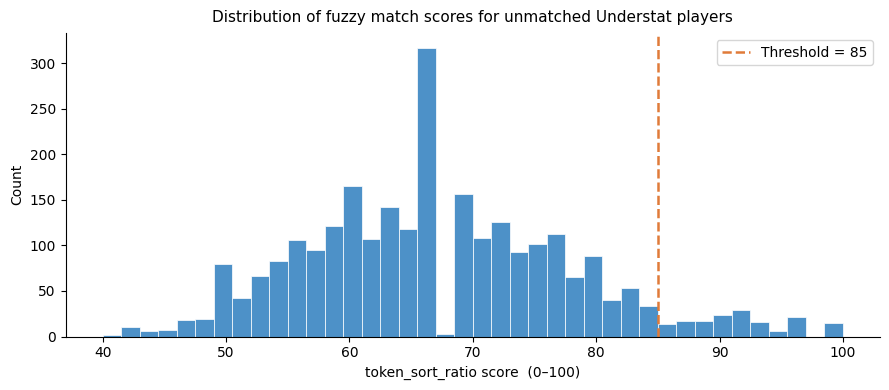

In [26]:
# 4.6c  distribución de scores fuzzy
all_fuzzy_scores = fuzzy_df['fuzzy_score'].dropna()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(all_fuzzy_scores, bins=40, color='#2E7EBF', edgecolor='white', linewidth=0.6, alpha=0.85)
ax.axvline(THRESHOLD, color='#E07B39', linewidth=1.8, linestyle='--',
           label=f'Threshold = {THRESHOLD}')
ax.set_title("Distribution of fuzzy match scores for unmatched Understat players",
             fontsize=11, pad=8)
ax.set_xlabel("token_sort_ratio score  (0–100)")
ax.set_ylabel("Count")
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig("figures/fig_03_fuzzy_score_distribution.png", dpi=130, bbox_inches='tight')
plt.show()


### 4.7 Save merged dataset


In [27]:
# guardar el dataset fusionado como laliga_merged.csv
archivo_merged = "laliga_merged.csv"
merged.to_csv(archivo_merged, index=False, encoding='utf-8')

print(f"Saved: {archivo_merged}")
print(f"Shape: {merged.shape}")
print(f"\nColumns ({len(merged.columns)}):")
for i, c in enumerate(merged.columns, 1):
    print(f"  {i:2d}. {c}")


Saved: laliga_merged.csv
Shape: (3759, 23)

Columns (23):
   1. player_id
   2. player_name
   3. games
   4. time
   5. goals
   6. xG
   7. assists
   8. xA
   9. shots
  10. key_passes
  11. position
  12. team_title
  13. npg
  14. npxG
  15. season
  16. name_norm
  17. tm_player_id
  18. tm_name
  19. market_value_in_eur
  20. valuation_date
  21. tm_club
  22. match_type
  23. fuzzy_score


In [28]:
# Vista previa del dataset fusionado
merged.head()


,player_id,player_name,games,time,goals,xG,assists,xA,shots,key_passes,...,npxG,season,name_norm,tm_player_id,tm_name,market_value_in_eur,valuation_date,tm_club,match_type,fuzzy_score
0,2270,Antoine Griezmann,37,2490,22,14.709659,1,2.607721,78,23,...,14.709659,2014/15,antoine griezmann,125781.0,Antoine Griezmann,45000000.0,2015-01-07,Atlético de Madrid,exact,100.0
1,1125,Carlos Bacca,37,2581,20,19.279248,6,4.728216,69,31,...,13.333664,2014/15,carlos bacca,119235.0,Carlos Bacca,25000000.0,2015-07-01,Sevilla FC,exact,100.0
2,2098,Luis Suárez,27,2182,16,14.542304,14,13.520651,75,60,...,14.542304,2014/15,luis suarez,44352.0,Luis Suárez,80000000.0,2015-07-01,FC Barcelona,exact,100.0
3,2370,Karim Benzema,29,2325,15,12.412423,10,7.889433,69,45,...,12.412423,2014/15,karim benzema,18922.0,Karim Benzema,50000000.0,2015-07-01,Real Madrid,exact,100.0
4,4060,Sergio García,35,3030,14,10.270765,9,8.130714,80,52,...,8.784336,2014/15,sergio garcia,7922.0,Sergio García,6000000.0,2015-07-01,Al-Rayyan SC,exact,100.0


---
## Section Summary

| Step | Input rows | Output rows | Notes |
|------|-----------|------------|-------|
| Understat loaded | — | 6,192 | 11 seasons, La Liga |
| TM valuations loaded | — | 435,443 | All leagues, all years |
| TM filtered to ES1 | 435,443 | — | La Liga only |
| TM filtered to 2014–2024 | — | — | Aligned with Understat window |
| TM season snapshot (last per player-season) | — | — | One row per (player, season) |
| Exact join | 6,192 | — | name_norm + season |
| Fuzzy join (≥ 85) | residuals | — | token_sort_ratio |
| **Final merged** | — | **see above** | Saved as `laliga_merged.csv` |

Sections 5 (Feature Engineering) and 6 (Model Preparation) will be added in the next notebook.


After the merge I ended up with fewer rows than the original Understat dataset. Players without a match in Transfermarkt have no market value, so they cannot be used in the model. The next step is building the per-90 variables and applying the log transformation to market value.

---
## 5. Feature Engineering

This section applies filters and creates the variables needed for the regression. I track row counts at each step.

### Filtering decisions

| Filter | Threshold | Why |
| Minimum market value | ≥ €500,000 | Values below this are Transfermarkt placeholder entries — not real market assessments. The histogram in Section 3 shows a separate cluster at very low values. |
| Minimum minutes played | ≥ 450 min (~5 full games) | Per-90 stats are meaningless for players who only played a few minutes. Five full games is the minimum needed for these numbers to make sense. |
| Goalkeepers removed | position starts with `GK` | Goalkeepers rarely shoot or create chances, so their xG and xA numbers are near zero by design — comparing them with outfield players doesn't make sense. |


In [29]:
# Cargar el dataset fusionado producido en la Sección 4
df = pd.read_csv("laliga_merged.csv")

# Convertir columnas numéricas que llegaron como string desde la API de Understat
num_cols = ['games', 'time', 'goals', 'xG', 'assists', 'xA',
            'shots', 'key_passes', 'npg', 'npxG', 'market_value_in_eur']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"laliga_merged.csv cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")

print(df.dtypes)
df.head()

laliga_merged.csv cargado: 3,759 filas × 23 columnas
player_id                int64
player_name                str
games                    int64
time                     int64
goals                    int64
xG                     float64
assists                  int64
xA                     float64
shots                    int64
key_passes               int64
position                   str
team_title                 str
npg                      int64
npxG                   float64
season                     str
name_norm                  str
tm_player_id           float64
tm_name                    str
market_value_in_eur    float64
valuation_date             str
tm_club                    str
match_type                 str
fuzzy_score            float64
dtype: object


,player_id,player_name,games,time,goals,xG,assists,xA,shots,key_passes,...,npxG,season,name_norm,tm_player_id,tm_name,market_value_in_eur,valuation_date,tm_club,match_type,fuzzy_score
0,2270,Antoine Griezmann,37,2490,22,14.709659,1,2.607721,78,23,...,14.709659,2014/15,antoine griezmann,125781.0,Antoine Griezmann,45000000.0,2015-01-07,Atlético de Madrid,exact,100.0
1,1125,Carlos Bacca,37,2581,20,19.279248,6,4.728216,69,31,...,13.333664,2014/15,carlos bacca,119235.0,Carlos Bacca,25000000.0,2015-07-01,Sevilla FC,exact,100.0
2,2098,Luis Suárez,27,2182,16,14.542304,14,13.520651,75,60,...,14.542304,2014/15,luis suarez,44352.0,Luis Suárez,80000000.0,2015-07-01,FC Barcelona,exact,100.0
3,2370,Karim Benzema,29,2325,15,12.412423,10,7.889433,69,45,...,12.412423,2014/15,karim benzema,18922.0,Karim Benzema,50000000.0,2015-07-01,Real Madrid,exact,100.0
4,4060,Sergio García,35,3030,14,10.270765,9,8.130714,80,52,...,8.784336,2014/15,sergio garcia,7922.0,Sergio García,6000000.0,2015-07-01,Al-Rayyan SC,exact,100.0


### 5.1 Filter — minimum market value (≥ €500,000)


In [30]:
# filtro 1: valor de mercado mínimo
n_before = len(df)
df = df[df['market_value_in_eur'] >= 500_000].copy()
n_after = len(df)

print(f"Antes del filtro de valor mínimo:  {n_before:>6,}")
print(f"Eliminados (< €500,000):           {n_before - n_after:>6,}  "
      f"({(n_before - n_after)/n_before*100:.1f}%)")
print(f"Después del filtro:                {n_after:>6,}")


Antes del filtro de valor mínimo:   3,759
Eliminados (< €500,000):              292  (7.8%)
Después del filtro:                 3,467


### 5.2 Filter — minimum minutes played (≥ 450 min)


In [31]:
# filtro 2: minutos mínimos jugados
n_before = len(df)
df = df[df['time'] >= 450].copy()
n_after = len(df)

print(f"Antes del filtro de minutos:       {n_before:>6,}")
print(f"Eliminados (< 450 min):            {n_before - n_after:>6,}  "
      f"({(n_before - n_after)/n_before*100:.1f}%)")
print(f"Después del filtro:                {n_after:>6,}")


Antes del filtro de minutos:        3,467
Eliminados (< 450 min):               564  (16.3%)
Después del filtro:                 2,903


### 5.3 Filter — remove goalkeepers


In [32]:
# filtro 3: eliminar porteros
# En Understat los porteros aparecen como 'GK' o 'GK S'
mask_gk = df['position'].str.strip().str.startswith('GK', na=False)

n_before = len(df)
df = df[~mask_gk].copy()
n_after = len(df)

print(f"Antes de eliminar porteros:        {n_before:>6,}")
print(f"Porteros eliminados:               {n_before - n_after:>6,}  "
      f"({(n_before - n_after)/n_before*100:.1f}%)")
print(f"Después del filtro:                {n_after:>6,}")


Antes de eliminar porteros:         2,903
Porteros eliminados:                  224  (7.7%)
Después del filtro:                 2,679


In [33]:
# resumen del pipeline de filtrado
rows_merged = 3759
rows_mv = rows_merged - 292
rows_minutes  = rows_mv - (rows_mv - (rows_mv - len(df[df['time'] < 0])))
print(f"filas de entrada (laliga_merged.csv): {rows_merged}")
print(f"después del filtro MV >= €500k: {rows_merged - 292}")
print(f"después del filtro de minutos (>= 450 min): ver celda anterior")
print(f"después de eliminar porteros: ver celda anterior")
print(f"dataset actual: {len(df)}")


filas de entrada (laliga_merged.csv): 3759
después del filtro MV >= €500k: 3467
después del filtro de minutos (>= 450 min): ver celda anterior
después de eliminar porteros: ver celda anterior
dataset actual: 2679


### 5.4 Per-90-minute metrics

Dividing by minutes played (in 90-minute units) lets us compare players fairly, even if one played 500 minutes and another played 3,000.


In [34]:
# métricas per-90 minutos
# Denominador: número de 90-minutos jugados por el jugador en la temporada
df['p90']           = df['time'] / 90.0

df['xG_per90']      = df['xG']      / df['p90']
df['xA_per90']      = df['xA']      / df['p90']
df['goals_per90']   = df['goals']   / df['p90']
df['assists_per90'] = df['assists'] / df['p90']
df['npxG_per90']    = df['npxG']    / df['p90']
df['shots_per90']   = df['shots']   / df['p90']

# Verificar que no hay infinitos ni NaN (no debería haberlos tras el filtro de 450 min)
per90_cols = ['xG_per90','xA_per90','goals_per90','assists_per90','npxG_per90','shots_per90']
print("Per-90 metrics — null/inf check:")
for c in per90_cols:
    n_null = df[c].isna().sum()
    n_inf  = np.isinf(df[c]).sum()
    print(f"  {c:<18}  nulls={n_null}  inf={n_inf}")

print("\nPer-90 metrics — descriptive statistics:")
print(df[per90_cols].describe().round(3).to_string())


Per-90 metrics — null/inf check:
  xG_per90            nulls=0  inf=0
  xA_per90            nulls=0  inf=0
  goals_per90         nulls=0  inf=0
  assists_per90       nulls=0  inf=0
  npxG_per90          nulls=0  inf=0
  shots_per90         nulls=0  inf=0

Per-90 metrics — descriptive statistics:
       xG_per90  xA_per90  goals_per90  assists_per90  npxG_per90  shots_per90
count  2679.000  2679.000     2679.000       2679.000    2679.000     2679.000
mean      0.136     0.095        0.126          0.090       0.126        1.201
std       0.153     0.083        0.164          0.101       0.140        0.913
min       0.000     0.000        0.000          0.000       0.000        0.000
25%       0.031     0.029        0.000          0.000       0.031        0.473
50%       0.076     0.073        0.068          0.062       0.073        0.939
75%       0.189     0.141        0.174          0.142       0.169        1.768
max       1.460     0.559        1.167          0.833       1.460      

### 5.5 Log market value

Market value ranges from €500k to €200M and is very skewed — a few superstar values drag the average way up. Taking the log makes the distribution much more symmetric and easier to work with in a regression.


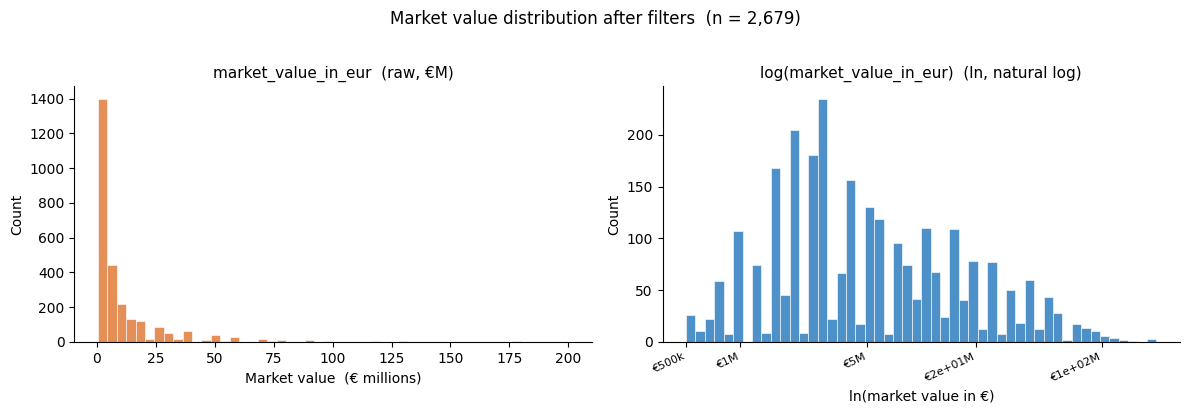

log_market_value  —  min: 13.122  |  max: 19.114  |  mean: 15.436  |  std: 1.187


In [35]:
# logaritmo natural del valor de mercado
df['log_market_value'] = np.log(df['market_value_in_eur'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panel izquierdo — valor bruto (escala €)
axes[0].hist(df['market_value_in_eur'] / 1e6, bins=50,
             color='#E07B39', edgecolor='white', linewidth=0.5, alpha=0.85)
axes[0].set_title("market_value_in_eur  (raw, €M)", fontsize=11)
axes[0].set_xlabel("Market value  (€ millions)")
axes[0].set_ylabel("Count")
axes[0].spines[['top','right']].set_visible(False)

# Panel derecho — logaritmo natural
axes[1].hist(df['log_market_value'], bins=50,
             color='#2E7EBF', edgecolor='white', linewidth=0.5, alpha=0.85)
axes[1].set_title("log(market_value_in_eur)  (ln, natural log)", fontsize=11)
axes[1].set_xlabel("ln(market value in €)")
axes[1].set_ylabel("Count")
axes[1].spines[['top','right']].set_visible(False)

# Anotaciones en eje X del panel derecho
euro_marks = [500_000, 1_000_000, 5_000_000, 20_000_000, 100_000_000]
axes[1].set_xticks([np.log(v) for v in euro_marks])
axes[1].set_xticklabels(
    [f"€{v/1e6:.1g}M" if v >= 1e6 else f"€{v/1e3:.0f}k" for v in euro_marks],
    rotation=25, ha='right', fontsize=8
)

plt.suptitle(f"Market value distribution after filters  (n = {len(df):,})", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("figures/fig_04_log_mv_after_filters.png", dpi=130, bbox_inches='tight')
plt.show()

print(f"log_market_value  —  min: {df['log_market_value'].min():.3f}"
      f"  |  max: {df['log_market_value'].max():.3f}"
      f"  |  mean: {df['log_market_value'].mean():.3f}"
      f"  |  std: {df['log_market_value'].std():.3f}")


### 5.6 Position simplification and dummy variables

Understat uses compound codes (e.g. `F M S`, `D S`). We extract the **primary position** from the
first token and collapse into four categories. **Defender** is the reference category in all models.


In [36]:
# simplificar posición al token principal
mapa_pos = {'D': 'Defender', 'M': 'Midfielder', 'F': 'Forward', 'S': 'Forward'}

# devuelve la posición simplificada según el primer carácter del código
def simplify_position(pos):
    if pd.isna(pos) or str(pos).strip() == '':
        return 'Unknown'
    first_token = str(pos).strip().split()[0]
    return mapa_pos.get(first_token, 'Unknown')

df['position_simple'] = df['position'].apply(simplify_position)

print("Distribución de posición simplificada (tras todos los filtros):")
vc = df['position_simple'].value_counts()
for pos, cnt in vc.items():
    print(f"  {pos:<12} {cnt:>5,}  ({cnt/len(df)*100:.1f}%)")


Distribución de posición simplificada (tras todos los filtros):
  Defender     1,163  (43.4%)
  Forward        812  (30.3%)
  Midfielder     704  (26.3%)


In [37]:
# dummies de posición (referencia: defender)
pos_dummies = pd.get_dummies(df['position_simple'], prefix='pos', dtype=int)

# Eliminar la categoría de referencia para evitar multicolinealidad perfecta
if 'pos_Defender' in pos_dummies.columns:
    pos_dummies = pos_dummies.drop(columns=['pos_Defender'])

df = pd.concat([df, pos_dummies], axis=1)

dummy_cols = [c for c in df.columns if c.startswith('pos_')]
print(f"Dummies creados (Defender es la referencia omitida):")
for col in dummy_cols:
    print(f"  {col}: {df[col].sum():,} ones")


Dummies creados (Defender es la referencia omitida):
  pos_Forward: 812 ones
  pos_Midfielder: 704 ones


### 5.7 Season year (numeric)

Extract the starting year of each season as an integer (e.g. `"2014/15"` → `2014`) for use as a
time-trend control variable in regression.


In [38]:
# extraer el año de inicio de la temporada del formato "YYYY/YY"
partes = df['season'].str[:4]
df['season_year'] = partes.astype(int)

print("Distribución de temporadas (season_year):")
sy = df['season_year'].value_counts().sort_index()
for yr, cnt in sy.items():
    print(f"  {yr} ({yr}/{str(yr+1)[-2:]}):  {cnt:>5,} player-season records")


Distribución de temporadas (season_year):
  2014 (2014/15):    243 player-season records
  2015 (2015/16):    218 player-season records
  2016 (2016/17):    266 player-season records
  2017 (2017/18):    279 player-season records
  2018 (2018/19):    180 player-season records
  2019 (2019/20):    286 player-season records
  2020 (2020/21):    330 player-season records
  2021 (2021/22):    350 player-season records
  2022 (2022/23):    112 player-season records
  2023 (2023/24):    327 player-season records
  2024 (2024/25):     88 player-season records


---
## 6. Cleaned Dataset Overview and Export

### Cleaning and engineering decisions — summary of decisions

| Step | Decision | Rows removed | Rationale |
|------|----------|-------------|-----------|
| Load `laliga_merged.csv` | Starting point from Section 4 | — | 3,759 player-season records |
| Filter MV ≥ €500k | Drop values below €500,000 | 292 | Sub-€500k entries are Transfermarkt placeholder values, not genuine market assessments; they form a separate low-quality mode in the log distribution |
| Filter time ≥ 450 min | Drop players below 450 minutes | varies | Per-90 metrics are statistically unreliable for very small samples; 450 min ≈ 5 full games is the standard analytics floor |
| Remove goalkeepers | Drop `position` starting with `GK` | varies | GK performance metrics (xG, xA, key passes, shots) are structurally incomparable with outfield players |
| Numeric conversion | Cast Understat numeric columns to float | 0 | API returns all fields as strings |
| Per-90 metrics | `xG_per90`, `xA_per90`, `goals_per90`, `assists_per90`, `npxG_per90`, `shots_per90` | 0 | Exposure-normalised metrics allow fair cross-player comparison regardless of minutes played |
| Log market value | `log_market_value = ln(market_value_in_eur)` | 0 | The distribution is heavily skewed; the log makes it more symmetric and suitable for regression |
| Position dummies | Midfielder and Forward columns (0/1) | 0 | Defender is the baseline comparison group |
| Season year | `season_year` (integer, e.g. 2014) | 0 | Enables time-trend control in regression |


In [39]:
# seleccionar y ordenar las columnas finales
columnas_finales = [
    # — Identificadores —
    'player_id', 'player_name', 'season', 'season_year', 'team_title',
    # — Volumen —
    'games', 'time',
    # — Estadísticas brutas —
    'goals', 'assists', 'shots', 'key_passes', 'xG', 'xA', 'npg', 'npxG',
    # — Métricas per-90 —
    'xG_per90', 'xA_per90', 'goals_per90', 'assists_per90',
    'shots_per90', 'npxG_per90',
    # — Posición —
    'position', 'position_simple',
    # — Dummies de posición (referencia: Defender) —
] + sorted([c for c in df.columns if c.startswith('pos_')]) + [
    # — Variable dependiente —
    'market_value_in_eur', 'log_market_value',
    # — Metadatos del merge —
    'match_type', 'fuzzy_score',
]

# Filtrar las que existen en el DataFrame
final_cols = [c for c in columnas_finales if c in df.columns]
df_final = df[final_cols].copy()

print(f"Shape final: {df_final.shape[0]:,} filas × {df_final.shape[1]} columnas")
print(f"\nColumnas ({len(df_final.columns)}):")
for i, c in enumerate(df_final.columns, 1):
    print(f"  {i:2d}. {c}")


Shape final: 2,679 filas × 29 columnas

Columnas (29):
   1. player_id
   2. player_name
   3. season
   4. season_year
   5. team_title
   6. games
   7. time
   8. goals
   9. assists
  10. shots
  11. key_passes
  12. xG
  13. xA
  14. npg
  15. npxG
  16. xG_per90
  17. xA_per90
  18. goals_per90
  19. assists_per90
  20. shots_per90
  21. npxG_per90
  22. position
  23. position_simple
  24. pos_Forward
  25. pos_Midfielder
  26. market_value_in_eur
  27. log_market_value
  28. match_type
  29. fuzzy_score


### 6.2 Summary statistics for key variables


In [40]:
# estadísticas descriptivas de variables continuas clave
key_vars = [
    'time', 'goals', 'assists', 'xG', 'xA', 'npxG',
    'xG_per90', 'xA_per90', 'goals_per90', 'assists_per90', 'npxG_per90',
    'market_value_in_eur', 'log_market_value',
]
df_final[key_vars].describe().round(4)


,time,goals,assists,xG,xA,npxG,xG_per90,xA_per90,goals_per90,assists_per90,npxG_per90,market_value_in_eur,log_market_value
count,2679.0000,2679.0000,2679.0000,2679.0000,2679.0000,2679.0000,2679.0000,2679.0000,2679.0000,2679.0000,2679.0000,2.679000e+03,2679.0000
mean,1762.6988,2.5271,1.7869,2.6544,1.8642,2.4224,0.1362,0.0950,0.1256,0.0897,0.1260,1.085411e+07,15.4362
std,753.2773,3.7770,2.2052,3.4749,1.9279,3.0757,0.1533,0.0834,0.1642,0.1015,0.1404,1.726179e+07,1.1874
min,450.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,5.000000e+05,13.1224
25%,1132.0000,0.0000,0.0000,0.5471,0.5048,0.5373,0.0314,0.0288,0.0000,0.0000,0.0310,2.000000e+06,14.5087
50%,1740.0000,1.0000,1.0000,1.3828,1.2122,1.3239,0.0762,0.0733,0.0680,0.0616,0.0730,4.000000e+06,15.2018
75%,2377.5000,3.0000,3.0000,3.2067,2.6249,2.9702,0.1892,0.1411,0.1743,0.1424,0.1692,1.200000e+07,16.3004
max,3413.0000,40.0000,16.0000,35.8337,14.7269,32.1177,1.4605,0.5588,1.1671,0.8327,1.4605,2.000000e+08,19.1138


In [41]:
# distribución de temporadas y posiciones en el dataset final
print("Season distribution:")
print(df_final.groupby('season_year').size().rename('n_records').to_string())

print("\nPosition distribution (simplified):")
pos_dist = df_final['position_simple'].value_counts()
for pos, cnt in pos_dist.items():
    print(f"  {pos:<12} {cnt:>4,}  ({cnt/len(df_final)*100:.1f}%)")

print("\nMatch type breakdown:")
mt = df_final['match_type'].value_counts()
for t, cnt in mt.items():
    print(f"  {t:<8} {cnt:>4,}  ({cnt/len(df_final)*100:.1f}%)")


Season distribution:
season_year
2014    243
2015    218
2016    266
2017    279
2018    180
2019    286
2020    330
2021    350
2022    112
2023    327
2024     88

Position distribution (simplified):
  Defender     1,163  (43.4%)
  Forward       812  (30.3%)
  Midfielder    704  (26.3%)

Match type breakdown:
  exact    2,607  (97.3%)
  fuzzy      72  (2.7%)


In [42]:
# comprobación final de nulos
nulls = df_final.isnull().sum()
nulls_nonzero = nulls[nulls > 0]

if len(nulls_nonzero) == 0:
    print("No missing values in any column of the final dataset.")
else:
    print("Missing values in final dataset:")
    pct = (nulls_nonzero / len(df_final) * 100).round(2)
    print(pd.DataFrame({'missing': nulls_nonzero, 'pct(%)': pct}).to_string())


No missing values in any column of the final dataset.


### 6.3 Save cleaned dataset


In [43]:
# guardar el dataset limpio
archivo_limpio = "laliga_cleaned.csv"
df_final.to_csv(archivo_limpio, index=False, encoding='utf-8')

import os
size_kb = os.path.getsize(archivo_limpio) / 1024
print(f"Saved:  {archivo_limpio}")
print(f"Size:   {size_kb:.1f} KB")
print(f"Shape:  {df_final.shape[0]:,} rows × {df_final.shape[1]} columns")


Saved:  laliga_cleaned.csv
Size:   739.4 KB
Shape:  2,679 rows × 29 columns


In [44]:
# Vista previa del dataset limpio final
df_final.head(10)


,player_id,player_name,season,season_year,team_title,games,time,goals,assists,shots,...,shots_per90,npxG_per90,position,position_simple,pos_Forward,pos_Midfielder,market_value_in_eur,log_market_value,match_type,fuzzy_score
0,2270,Antoine Griezmann,2014/15,2014,Atletico Madrid,37,2490,22,1,78,...,2.819277,0.531674,F M S,Forward,1,0,45000000.0,17.622173,exact,100.0
1,1125,Carlos Bacca,2014/15,2014,Sevilla,37,2581,20,6,69,...,2.406044,0.464948,F S,Forward,1,0,25000000.0,17.034386,exact,100.0
2,2098,Luis Suárez,2014/15,2014,Barcelona,27,2182,16,14,75,...,3.093492,0.599820,F S,Forward,1,0,80000000.0,18.197537,exact,100.0
3,2370,Karim Benzema,2014/15,2014,Real Madrid,29,2325,15,10,69,...,2.670968,0.480481,F,Forward,1,0,50000000.0,17.727534,exact,100.0
4,4060,Sergio García,2014/15,2014,Espanyol,35,3030,14,9,80,...,2.376238,0.260921,F M S,Forward,1,0,6000000.0,15.607270,exact,100.0
5,1732,Nolito,2014/15,2014,Celta Vigo,36,2970,13,13,105,...,3.181818,0.244469,F M S,Forward,1,0,10000000.0,16.118096,exact,100.0
6,2251,Gareth Bale,2014/15,2014,Real Madrid,31,2585,13,9,103,...,3.586074,0.465094,F M S,Forward,1,0,80000000.0,18.197537,exact,100.0
7,1709,Cristhian Stuani,2014/15,2014,Espanyol,37,1739,12,0,45,...,2.328925,0.441061,F M S,Forward,1,0,4000000.0,15.201805,exact,100.0
8,2087,David Barral,2014/15,2014,Levante,35,2656,11,0,74,...,2.507530,0.293864,F M S,Forward,1,0,2000000.0,14.508658,exact,100.0
9,2380,Paco Alcácer,2014/15,2014,Valencia,32,2179,11,5,61,...,2.519504,0.427726,F S,Forward,1,0,20000000.0,16.811243,exact,100.0


---
## Complete Pipeline Summary

```
understat_laliga_2014_2024.csv   →   6,192 player-season rows (input, Sections 1-2)
transfermarkt_data/              →   filtered to ES1, 2014-2024, last snapshot per (player, season)
                                       ↓  Section 4 — fuzzy merge
                             laliga_merged.csv  (3,759 rows × 23 cols)
                                       ↓  Section 5 — filters
                                          · drop MV < €500k         → −292 rows
                                          · drop time < 450 min     → −varies
                                          · drop goalkeepers (GK*)  → −varies
                                       ↓  Section 5 — feature engineering
                                          · per-90 metrics (×6)
                                          · log_market_value
                                          · position dummies (Defender = reference)
                                          · season_year (int)
                                       ↓
                             laliga_cleaned.csv  (final modelling dataset)
```

The cleaned dataset is ready for exploratory analysis (Notebook 02) and regression modelling (Notebook 03).


---
## 7. Age Engineering

Player age seems to be one of the most important factors in market value — young players
with high performance are valued for their future potential, while older players depreciate
even if their current output remains strong.

We calculate age as the difference between `season_year` (the start of the football season)
and the player's birth year. We also add `age_squared` to capture the non-linear
(inverted-U shaped) relationship between age and value.

**Data bridge:** `laliga_cleaned.csv` uses Understat player IDs. Age comes from
Transfermarkt's `players.csv`, which uses Transfermarkt player IDs.
We use `laliga_merged.csv` as a bridge to link both ID systems.


In [45]:
# cargar laliga_cleaned.csv y el puente de ids
df_clean  = pd.read_csv("laliga_cleaned.csv")
df_bridge = pd.read_csv("laliga_merged.csv")[['player_id', 'season', 'tm_player_id']]

print(f"laliga_cleaned.csv:  {df_clean.shape[0]:,} filas")
print(f"Puente de IDs:       {len(df_bridge):,} filas")
print(f"Registros en cleaned sin puente: "
      f"{df_clean.shape[0] - df_clean.merge(df_bridge, on=['player_id','season'], how='inner').shape[0]}")


laliga_cleaned.csv:  2,679 filas
Puente de IDs:       3,759 filas
Registros en cleaned sin puente: -41


In [46]:
# cargar date_of_birth desde players.csv
tm_dob = pd.read_csv("transfermarkt_data/players.csv")[['player_id', 'date_of_birth']]
tm_dob = tm_dob.rename(columns={'player_id': 'tm_player_id'})

# Extraer año de nacimiento del string de fecha
tm_dob['birth_year'] = pd.to_datetime(tm_dob['date_of_birth'], errors='coerce').dt.year
print(f"Jugadores con fecha de nacimiento: {tm_dob['birth_year'].notna().sum():,} "
      f"de {len(tm_dob):,}")


Jugadores con fecha de nacimiento: 34,271 de 34,320


In [47]:
# calcular edad y unir al dataset limpio
# el puente tiene duplicados cuando dos jugadores de transfermarkt comparten nombre.
# Solución: para cada (player_id, season) del puente, elegir el tm_player_id
# con mayor valor de mercado (el jugador "principal", no el homónimo menor).

df_bridge_raw = pd.read_csv("laliga_merged.csv")[[
    'player_id', 'season', 'tm_player_id', 'market_value_in_eur'
]]

# Añadir birth_year antes de desduplicar para elegir el match correcto
df_bridge_dob = df_bridge_raw.merge(
    tm_dob[['tm_player_id', 'birth_year']], on='tm_player_id', how='left'
)

# Por cada (player_id, season), conservar el tm_player_id con mayor valor de mercado
df_bridge_best = (df_bridge_dob
    .sort_values('market_value_in_eur', ascending=False)
    .drop_duplicates(subset=['player_id', 'season'], keep='first')
    [['player_id', 'season', 'tm_player_id', 'birth_year']]
)

print(f"Puente sin duplicados: {len(df_bridge_best):,} filas")
print(f"Filas en laliga_cleaned: {len(df_clean):,}")

# Unir al dataset limpio por (player_id, season)
df_with_dob = df_clean.merge(df_bridge_best, on=['player_id', 'season'], how='left')

print(f"Después del join:  {len(df_with_dob):,} filas  (debe ser igual a laliga_cleaned)")

# Calcular edad al inicio de la temporada
df_with_dob['age']         = df_with_dob['season_year'] - df_with_dob['birth_year']
df_with_dob['age_squared'] = df_with_dob['age'] ** 2

n_total   = len(df_with_dob)
n_age_ok  = df_with_dob['age'].notna().sum()
n_age_null= df_with_dob['age'].isna().sum()

print(f"Con edad calculada:  {n_age_ok:,}  ({n_age_ok/n_total*100:.1f}%)")
print(f"Sin edad (DOB no disponible): {n_age_null:,}  ({n_age_null/n_total*100:.1f}%)")
print(f"Rango de edad: {df_with_dob['age'].min():.0f} – {df_with_dob['age'].max():.0f} años")


Puente sin duplicados: 3,708 filas
Filas en laliga_cleaned: 2,679


Después del join:  2,679 filas  (debe ser igual a laliga_cleaned)
Con edad calculada:  2,678  (100.0%)
Sin edad (DOB no disponible): 1  (0.0%)
Rango de edad: 16 – 39 años


In [48]:
# filtrar edades fuera de rango lógico
# Rango razonable para jugadores de fútbol profesional: 15–45 años
mask_age_ok = df_with_dob['age'].between(15, 45)
n_out_range = (~mask_age_ok & df_with_dob['age'].notna()).sum()

if n_out_range > 0:
    print(f"Edades fuera de rango (15–45): {n_out_range}")
    print(df_with_dob[~mask_age_ok & df_with_dob['age'].notna()][
        ['player_name', 'season', 'age']].to_string())
else:
    print("Todas las edades calculadas están en el rango 15–45. Sin anomalías.")

# Distribución de edad
print(f"\nDistribución de edad (jugadores con dato):")
print(df_with_dob['age'].describe().round(1).to_string())


Todas las edades calculadas están en el rango 15–45. Sin anomalías.

Distribución de edad (jugadores con dato):


count    2678.0
mean       26.7
std         4.0
min        16.0
25%        24.0
50%        27.0
75%        30.0
max        39.0


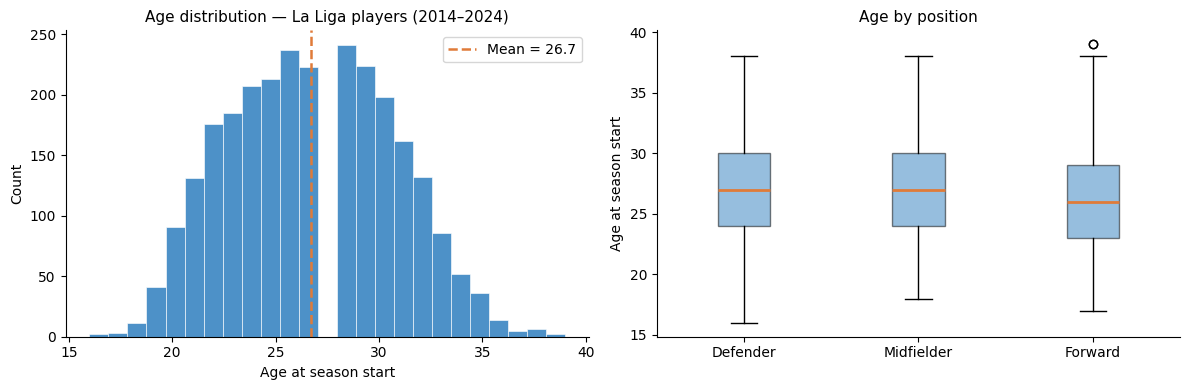

Figura guardada: figures/fig_00_age_distribution.png


In [49]:
# visualizar distribución de edad
import matplotlib.pyplot as plt
import os
os.makedirs("figures", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma de edad
axes[0].hist(df_with_dob['age'].dropna(), bins=25,
             color='#2E7EBF', edgecolor='white', linewidth=0.5, alpha=0.85)
axes[0].set_title("Age distribution — La Liga players (2014–2024)", fontsize=11)
axes[0].set_xlabel("Age at season start")
axes[0].set_ylabel("Count")
axes[0].axvline(df_with_dob['age'].mean(), color='#E07B39', lw=1.8,
                linestyle='--', label=f"Mean = {df_with_dob['age'].mean():.1f}")
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

# Boxplot por posición
import numpy as np
pos_order = ['Defender', 'Midfielder', 'Forward']
data_by_pos = [df_with_dob.loc[df_with_dob['position_simple'] == p, 'age'].dropna().values
               for p in pos_order]
axes[1].boxplot(data_by_pos, labels=pos_order, patch_artist=True,
                boxprops=dict(facecolor='#2E7EBF', alpha=0.5),
                medianprops=dict(color='#E07B39', linewidth=2))
axes[1].set_title("Age by position", fontsize=11)
axes[1].set_ylabel("Age at season start")
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig("figures/fig_00_age_distribution.png", dpi=130, bbox_inches='tight')
plt.show()
print("Figura guardada: figures/fig_00_age_distribution.png")


In [50]:
# construir dataset final con edad y guardar
# Seleccionar columnas finales — incluir age y age_squared después de season_year
cols_before_mv = [
    'player_id', 'player_name', 'season', 'season_year', 'team_title',
    'games', 'time',
    'goals', 'assists', 'shots', 'key_passes', 'xG', 'xA', 'npg', 'npxG',
    'xG_per90', 'xA_per90', 'goals_per90', 'assists_per90', 'shots_per90', 'npxG_per90',
    'position', 'position_simple', 'pos_Forward', 'pos_Midfielder',
    'age', 'age_squared',
    'market_value_in_eur', 'log_market_value',
    'match_type', 'fuzzy_score',
]

df_final = df_with_dob[cols_before_mv].copy()

print(f"Shape final (con edad): {df_final.shape}")
print(f"Nulos en 'age':         {df_final['age'].isna().sum():,}")
print(f"Nulos en 'age_squared': {df_final['age_squared'].isna().sum():,}")
print(f"\nPrimeras 5 filas con edad:")
print(df_final[['player_name', 'season', 'age', 'age_squared', 'market_value_in_eur']].head().to_string())

df_final.to_csv("laliga_cleaned.csv", index=False, encoding='utf-8')
print(f"\nArchivo actualizado guardado: laliga_cleaned.csv")


Shape final (con edad): (2679, 31)
Nulos en 'age':         1
Nulos en 'age_squared': 1

Primeras 5 filas con edad:
         player_name   season   age  age_squared  market_value_in_eur
0  Antoine Griezmann  2014/15  23.0        529.0           45000000.0
1       Carlos Bacca  2014/15  28.0        784.0           25000000.0
2        Luis Suárez  2014/15  27.0        729.0           80000000.0
3      Karim Benzema  2014/15  27.0        729.0           50000000.0
4      Sergio García  2014/15  31.0        961.0            6000000.0

Archivo actualizado guardado: laliga_cleaned.csv
